In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, auc, roc_auc_score, brier_score_loss
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
from scipy.ndimage import gaussian_filter1d

In [2]:
lead_times = ["t1", "t2", "t4", "t6"]
base_dir = "/gws/nopw/j04/wiser_ewsa/mrakotomanga/Intercomparison/time_series"

nflics = {lt: pd.read_csv(f"{base_dir}/nflics/{lt}/zambia_nowcasts_{lt}.csv") for lt in lead_times}
netncc = {lt: pd.read_csv(f"{base_dir}/netncc/{lt}/zambia_nowcasts_{lt}.csv") for lt in lead_times}
zcast  = {lt: pd.read_csv(f"{base_dir}/zcast_ensemble/{lt}/zambia_nowcasts_{lt}.csv") for lt in lead_times}


cities = [col.replace("_t1", "") for col in nflics["t1"].columns if col.endswith("_t1")]

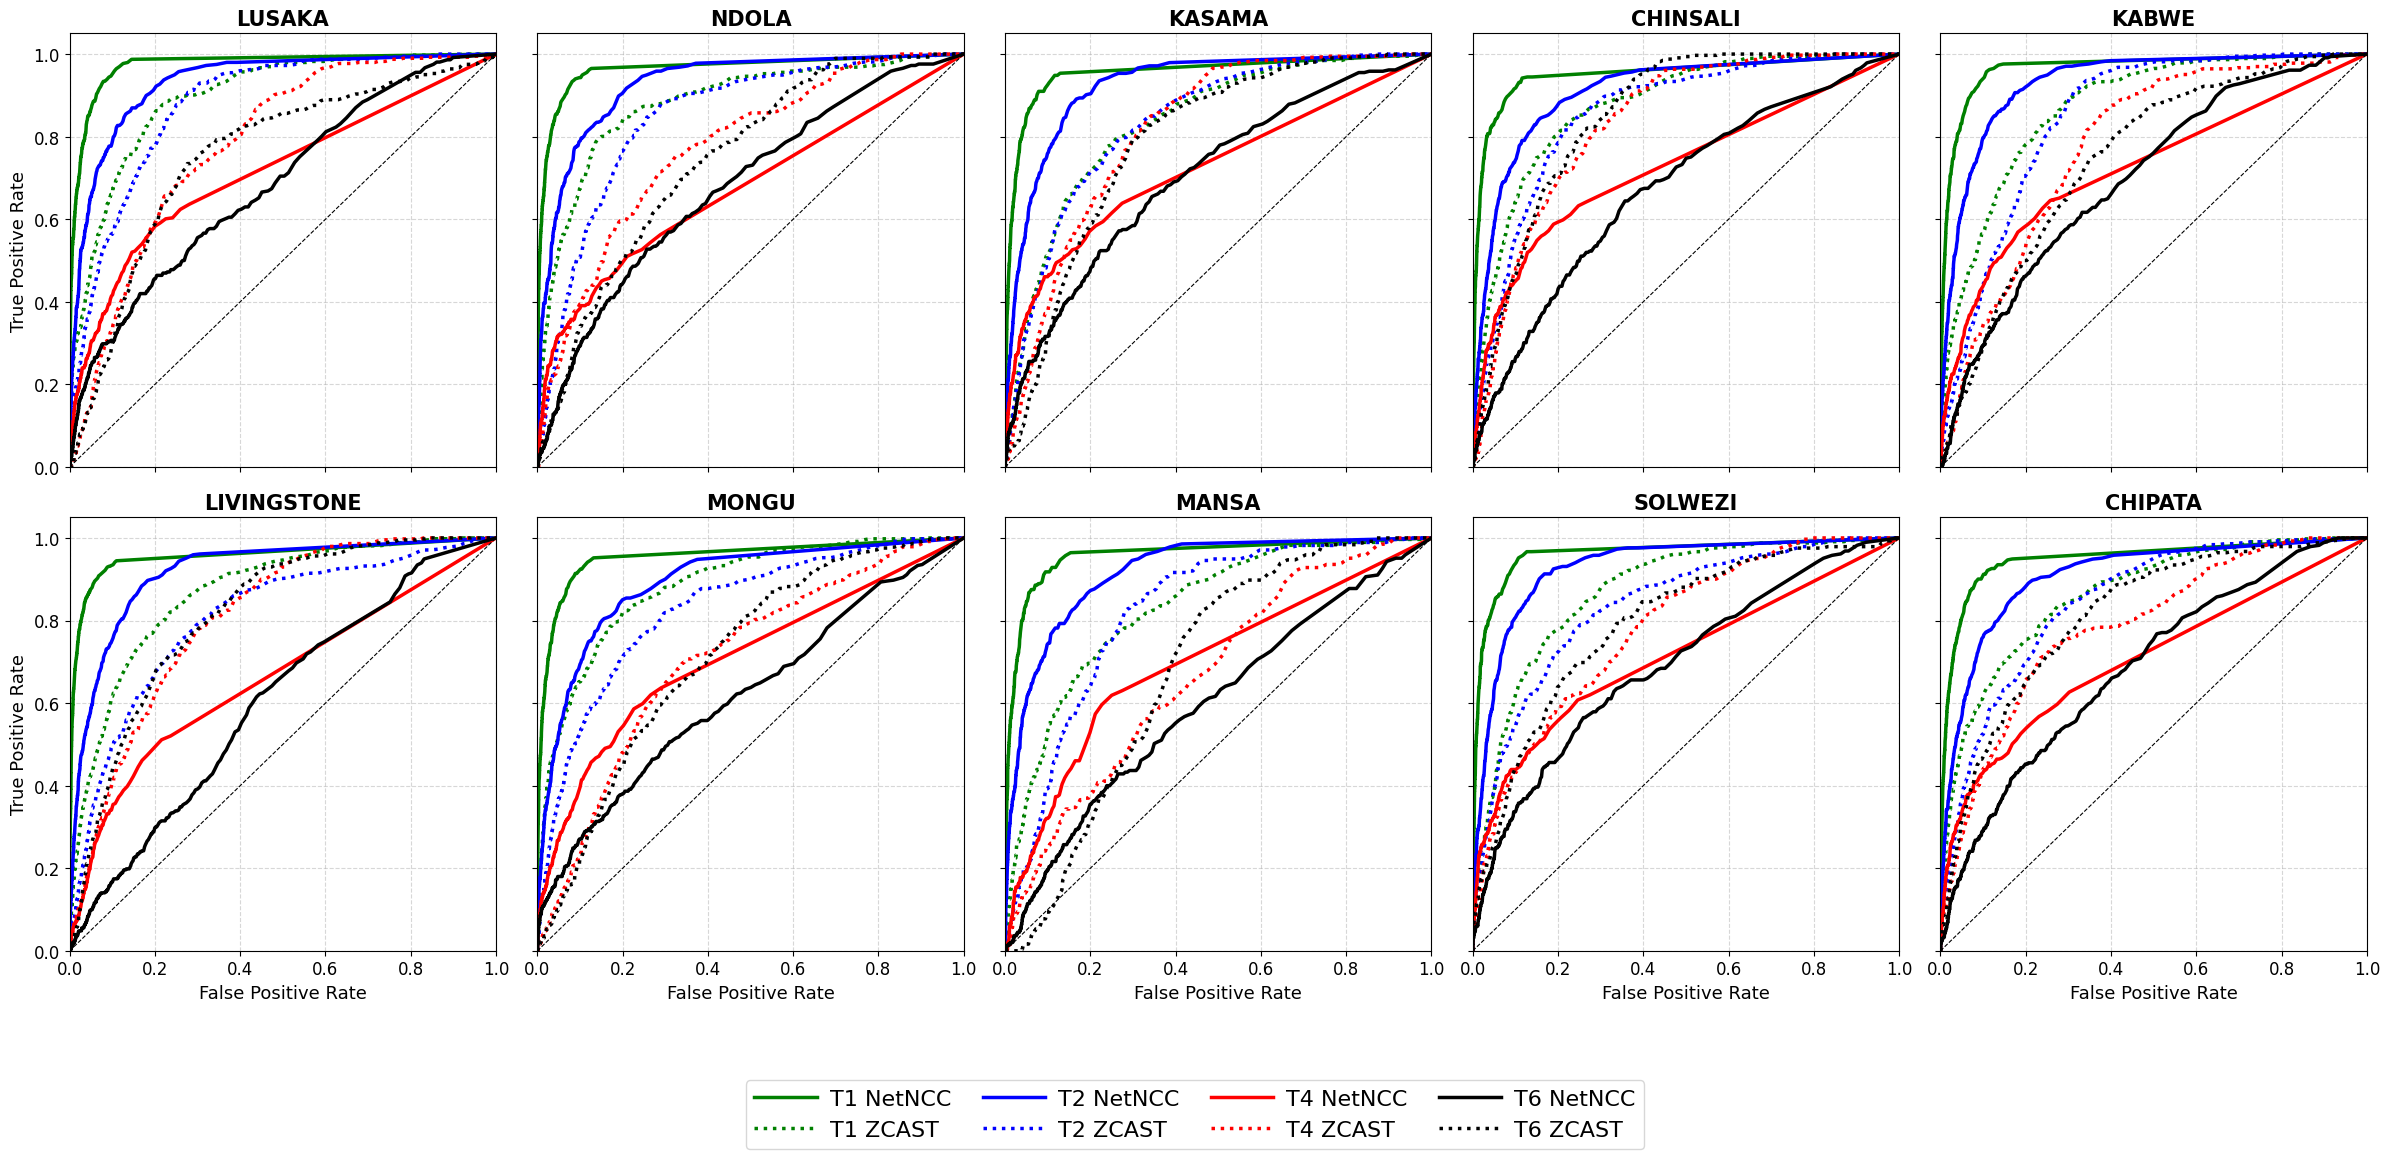

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

lead_times = ["t1", "t2", "t4", "t6"]
base_dir = "/gws/nopw/j04/wiser_ewsa/mrakotomanga/Intercomparison/time_series"

# Load data for NetNCC and ZCAST only
netncc = {lt: pd.read_csv(f"{base_dir}/netncc/{lt}/zambia_nowcasts_{lt}.csv") for lt in lead_times}
zcast  = {lt: pd.read_csv(f"{base_dir}/zcast/{lt}/zambia_nowcasts_{lt}.csv") for lt in lead_times}

# Extract city names dynamically
cities = [col.replace("_t1", "") for col in netncc["t1"].columns if col.endswith("_t1")]

# Create figure with high DPI
fig, axes = plt.subplots(2, 5, figsize=(24, 11))
axes = axes.flatten()

# Custom colour mapping
colors = {"t1": "green", "t2": "blue", "t4": "red", "t6": "black"}
handles_all, labels_all = [], []

for i, city in enumerate(cities[:10]):
    ax = axes[i]

    for lt in lead_times:
        df_nc = netncc[lt]
        df_zc = zcast[lt]
        gt_col = f"{city}_gt_lt{lt[-1]}"
        if gt_col not in df_nc.columns or f"{city}_{lt}" not in df_nc.columns or f"{city}_{lt}" not in df_zc.columns:
            continue

        # Align timestamps between products
        merged = pd.merge(
            df_nc[["t0", gt_col, f"{city}_{lt}"]],
            df_zc[["t0", f"{city}_{lt}"]],
            on="t0",
            suffixes=("_ncc", "_zc")
        )

        y_true = merged[gt_col]
        y_pred_netncc = merged[f"{city}_{lt}_ncc"].replace(-998.0, np.nan)
        y_pred_zcast = merged[f"{city}_{lt}_zc"].replace(-998.0, np.nan)

        mask_nc = ~y_pred_netncc.isna()
        mask_zc = ~y_pred_zcast.isna()

        if y_true[mask_nc].nunique() < 2 or y_true[mask_zc].nunique() < 2:
            continue

        fpr_nc, tpr_nc, _ = roc_curve(y_true[mask_nc], y_pred_netncc[mask_nc])
        fpr_zc, tpr_zc, _ = roc_curve(y_true[mask_zc], y_pred_zcast[mask_zc])

        auc_nc, auc_zc = auc(fpr_nc, tpr_nc), auc(fpr_zc, tpr_zc)

        # Plot curves
        l1, = ax.plot(fpr_nc, tpr_nc, color=colors[lt], lw=2.5, label=f"{lt.upper()} NetNCC (AUC={auc_nc:.2f})")
        l2, = ax.plot(fpr_zc, tpr_zc, color=colors[lt], lw=2.5, ls=":", label=f"{lt.upper()} ZCAST (AUC={auc_zc:.2f})")

        if i == 0:
            handles_all.extend([l1, l2])
            labels_all.extend([f"{lt.upper()} NetNCC", f"{lt.upper()} ZCAST"])

    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_title(city.upper(), fontsize=15, weight="bold")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.tick_params(axis="both", labelsize=12)

    # Show labels only on outer plots
    if i >= 5:
        ax.set_xlabel("False Positive Rate", fontsize=13)
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])

    if i % 5 == 0:
        ax.set_ylabel("True Positive Rate", fontsize=13)
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])

plt.subplots_adjust(hspace=0.45, wspace=0.25)

# Unified legend at the bottom
fig.legend(
    handles_all,
    labels_all,
    loc="lower center",
    fontsize=16,
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    edgecolor="lightgrey",
    ncol=4,
    handlelength=2.8,
    handletextpad=0.6,
    columnspacing=1.4,
    bbox_to_anchor=(0.5, -0.06)
)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

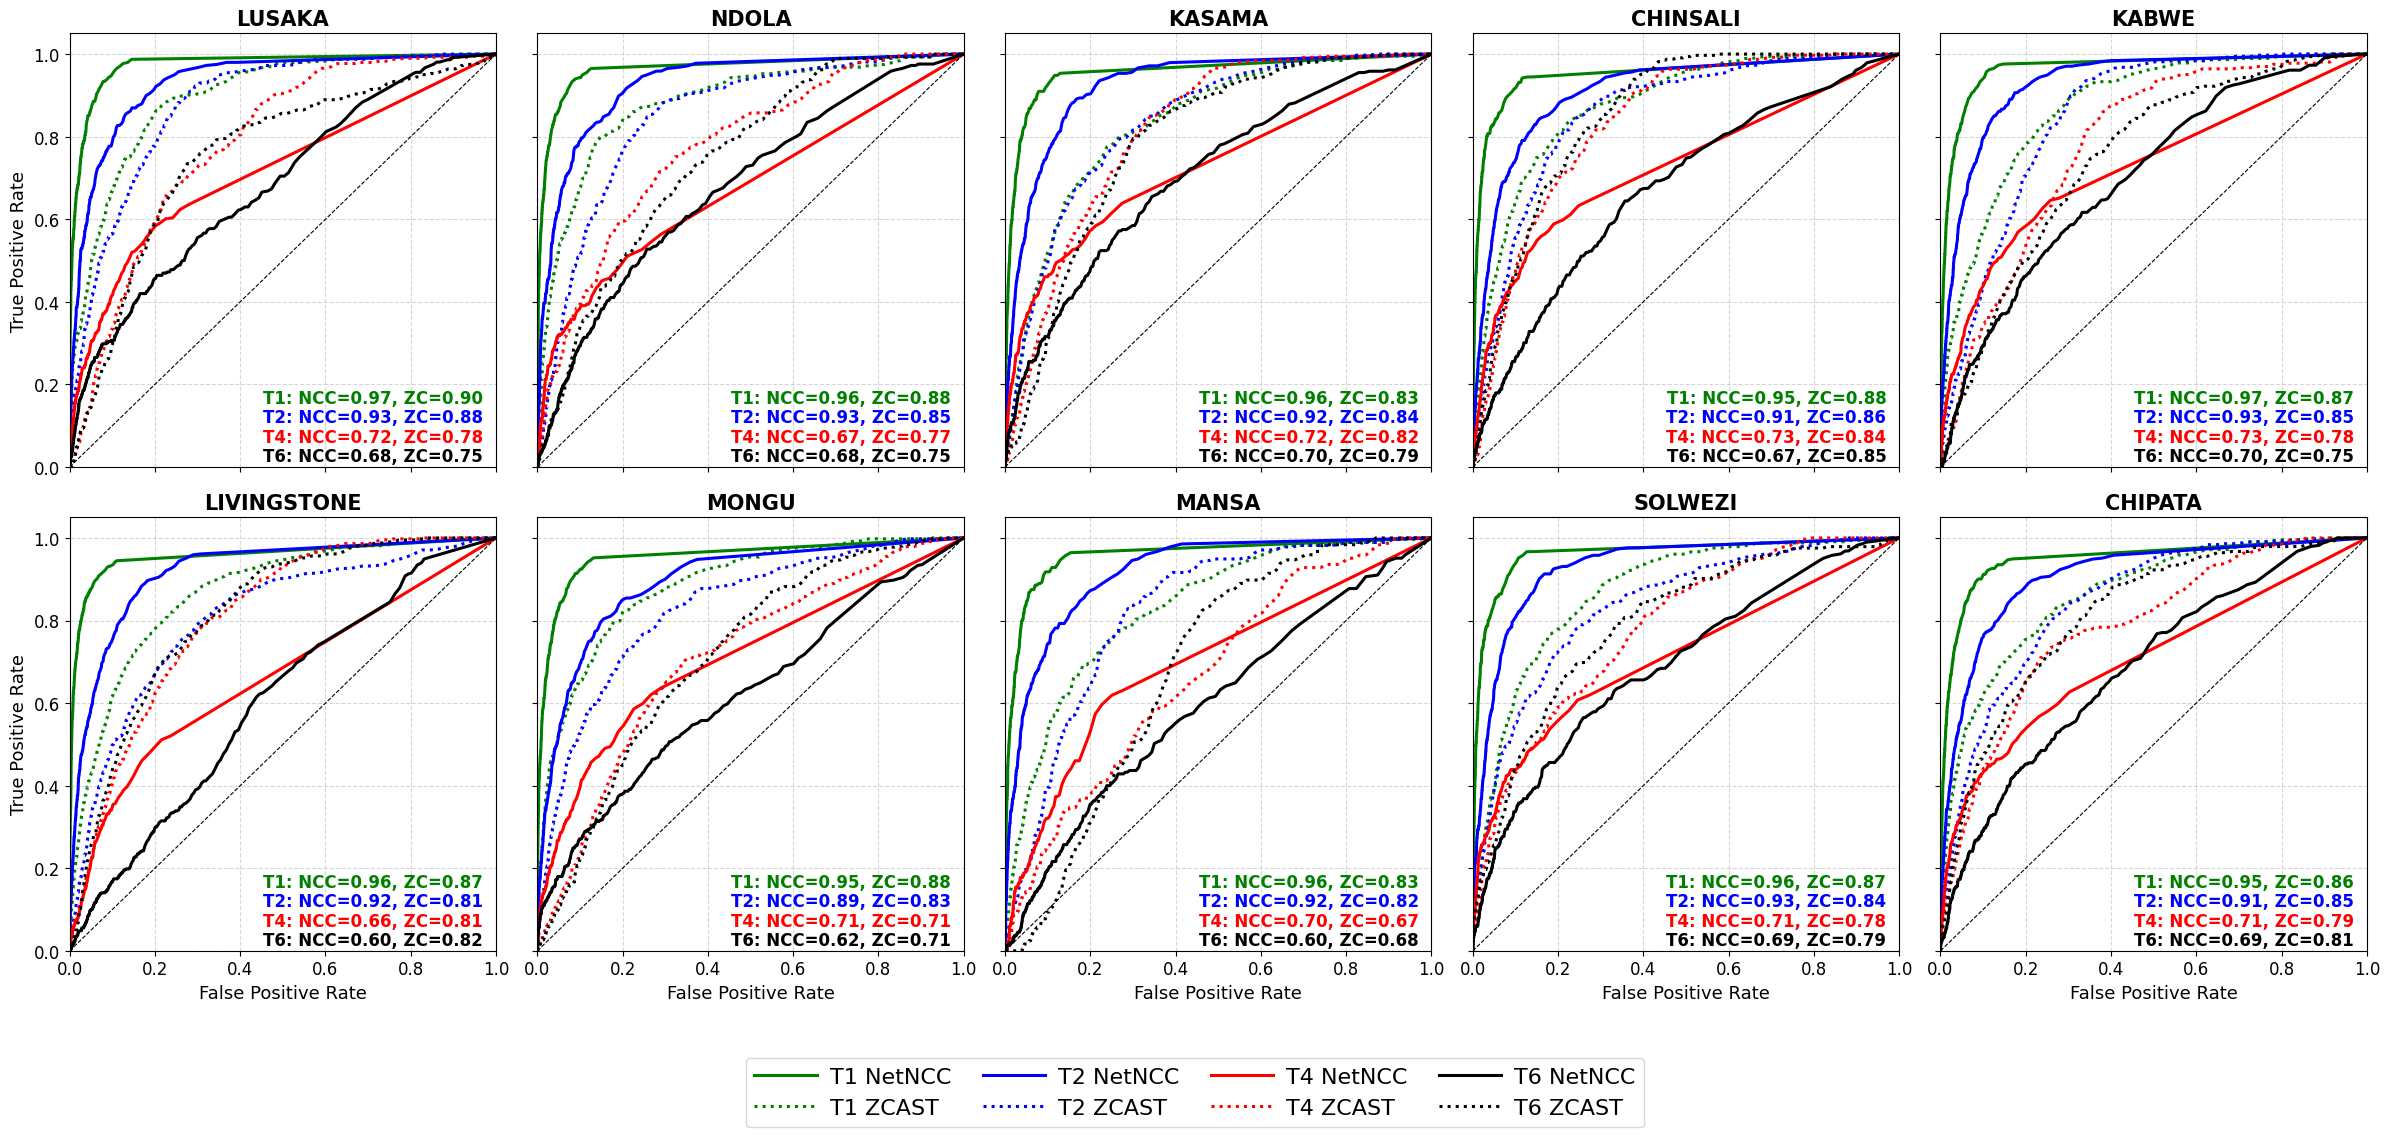

In [ ]:
lead_times = ["t1", "t2", "t4", "t6"]
base_dir = "/gws/nopw/j04/wiser_ewsa/mrakotomanga/Intercomparison/time_series"

# Load data
netncc = {lt: pd.read_csv(f"{base_dir}/netncc/{lt}/zambia_nowcasts_{lt}.csv") for lt in lead_times}
zcast  = {lt: pd.read_csv(f"{base_dir}/zcast/{lt}/zambia_nowcasts_{lt}.csv") for lt in lead_times}

# Extract city names
cities = [col.replace("_t1", "") for col in netncc["t1"].columns if col.endswith("_t1")]

# Create figure
fig, axes = plt.subplots(2, 5, figsize=(24, 11))
axes = axes.flatten()

# Colour map
colors = {"t1": "green", "t2": "blue", "t4": "red", "t6": "black"}
handles_all, labels_all = [], []

for i, city in enumerate(cities[:10]):
    ax = axes[i]
    auc_entries = []  # store tuples (text, colour)

    for lt in lead_times:
        df_nc = netncc[lt]
        df_zc = zcast[lt]
        gt_col = f"{city}_gt_lt{lt[-1]}"
        if gt_col not in df_nc.columns or f"{city}_{lt}" not in df_nc.columns or f"{city}_{lt}" not in df_zc.columns:
            continue

        merged = pd.merge(
            df_nc[["t0", gt_col, f"{city}_{lt}"]],
            df_zc[["t0", f"{city}_{lt}"]],
            on="t0",
            suffixes=("_ncc", "_zc")
        )

        y_true = merged[gt_col]
        y_pred_nc = merged[f"{city}_{lt}_ncc"].replace(-998.0, np.nan)
        y_pred_zc = merged[f"{city}_{lt}_zc"].replace(-998.0, np.nan)

        mask_nc = ~y_pred_nc.isna()
        mask_zc = ~y_pred_zc.isna()
        if y_true[mask_nc].nunique() < 2 or y_true[mask_zc].nunique() < 2:
            continue

        fpr_nc, tpr_nc, _ = roc_curve(y_true[mask_nc], y_pred_nc[mask_nc])
        fpr_zc, tpr_zc, _ = roc_curve(y_true[mask_zc], y_pred_zc[mask_zc])
        auc_nc, auc_zc = auc(fpr_nc, tpr_nc), auc(fpr_zc, tpr_zc)

        # Plot ROC
        l1, = ax.plot(fpr_nc, tpr_nc, color=colors[lt], lw=2.2)
        l2, = ax.plot(fpr_zc, tpr_zc, color=colors[lt], lw=2.2, ls=":")

        auc_entries.append((f"{lt.upper()}: NCC={auc_nc:.2f}, ZC={auc_zc:.2f}", colors[lt]))

        if i == 0:
            handles_all.extend([l1, l2])
            labels_all.extend([f"{lt.upper()} NetNCC", f"{lt.upper()} ZCAST"])

    # Reference diagonal
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_title(city.upper(), fontsize=15, weight="bold")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.tick_params(axis="both", labelsize=12)

    # Draw coloured AUC text block (T1 first → top)
    if auc_entries:
        ax.text(
            0.97, 0.03, "", transform=ax.transAxes,
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="black", linewidth=0.6, boxstyle="round,pad=0.3")
        )
        # Draw from top (T1) to bottom (T6)
        for j, (line, col) in enumerate(auc_entries):
            y_pos = 0.18 - 0.045 * j  # top-down placement
            ax.text(
                0.97, y_pos, line,
                transform=ax.transAxes,
                fontsize=12,
                color=col,
                ha="right", va="top",
                fontweight="semibold"
            )

    # Axis labels
    if i >= 5:
        ax.set_xlabel("False Positive Rate", fontsize=13)
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])

    if i % 5 == 0:
        ax.set_ylabel("True Positive Rate", fontsize=13)
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])

plt.subplots_adjust(hspace=0.4, wspace=0.25)

# Unified legend
fig.legend(
    handles_all,
    labels_all,
    loc="lower center",
    fontsize=16,
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    edgecolor="lightgrey",
    ncol=4,
    handlelength=2.8,
    handletextpad=0.6,
    columnspacing=1.4,
    bbox_to_anchor=(0.5, -0.04)
)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()


# All lead time, all locations

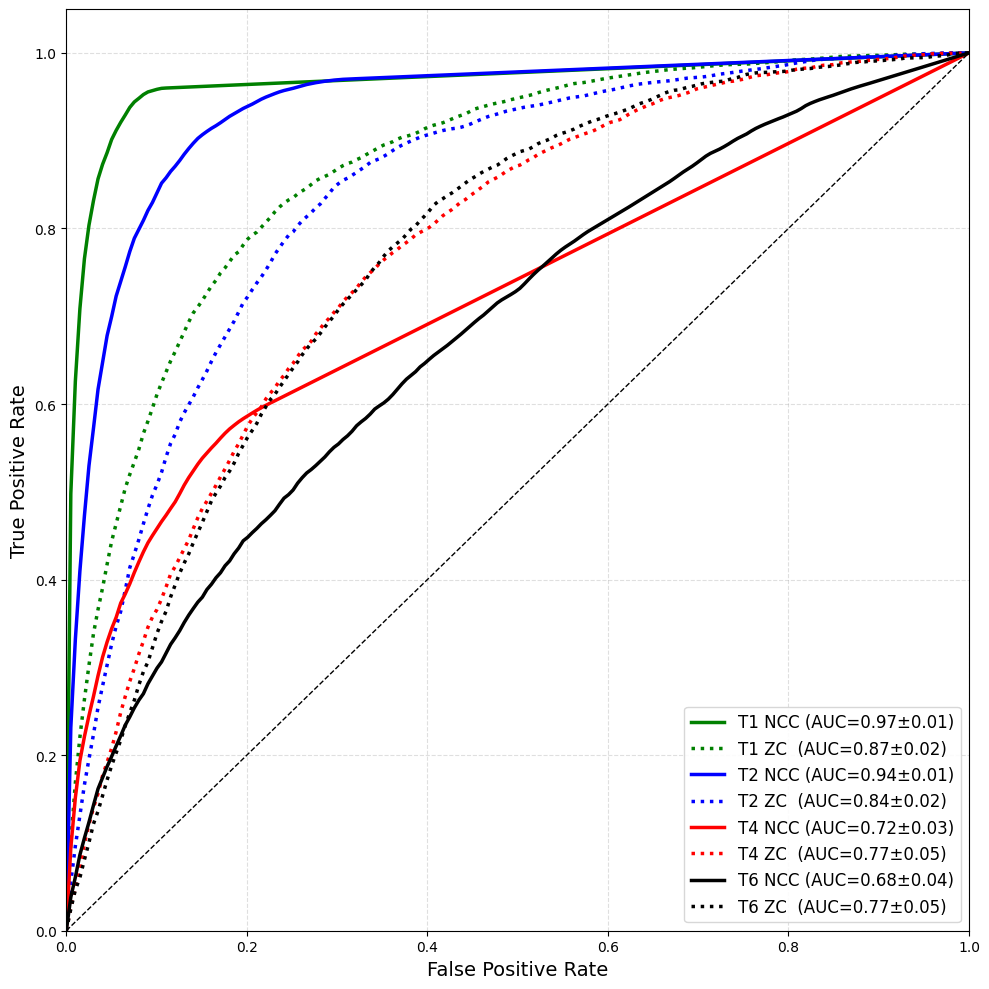

In [15]:
plt.figure(figsize=(10, 10))

# ---------------------------------------------------------------------
# Compute and plot mean ROC across all cities for both models
# ---------------------------------------------------------------------
for lt in lead_times:
    mean_fpr = np.linspace(0, 1, 200)

    # --- NetNCC ---
    aucs_nc, tprs_nc = [], []
    for city in cities:
        df_nc = netncc[lt]
        gt_col = f"{city}_gt_lt{lt[-1]}"
        if gt_col not in df_nc.columns or f"{city}_{lt}" not in df_nc.columns:
            continue

        y_true = df_nc[gt_col]
        y_pred = df_nc[f"{city}_{lt}"].replace(-998.0, np.nan)
        mask = ~y_pred.isna()
        if y_true[mask].nunique() < 2:
            continue

        fpr, tpr, _ = roc_curve(y_true[mask], y_pred[mask])
        roc_auc = auc(fpr, tpr)
        aucs_nc.append(roc_auc)
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs_nc.append(tpr_interp)

    if not aucs_nc:
        continue
    mean_tpr_nc = np.mean(tprs_nc, axis=0)
    mean_tpr_nc[-1] = 1.0
    mean_auc_nc = np.mean(aucs_nc)
    std_auc_nc = np.std(aucs_nc)

    # --- ZCAST ---
    aucs_zc, tprs_zc = [], []
    for city in cities:
        df_zc = zcast[lt]
        gt_col = f"{city}_gt_lt{lt[-1]}"
        if gt_col not in df_zc.columns or f"{city}_{lt}" not in df_zc.columns:
            continue

        y_true = df_zc[gt_col]
        y_pred = df_zc[f"{city}_{lt}"].replace(-998.0, np.nan)
        mask = ~y_pred.isna()
        if y_true[mask].nunique() < 2:
            continue

        fpr, tpr, _ = roc_curve(y_true[mask], y_pred[mask])
        roc_auc = auc(fpr, tpr)
        aucs_zc.append(roc_auc)
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs_zc.append(tpr_interp)

    if not aucs_zc:
        continue
    mean_tpr_zc = np.mean(tprs_zc, axis=0)
    mean_tpr_zc[-1] = 1.0
    mean_auc_zc = np.mean(aucs_zc)
    std_auc_zc = np.std(aucs_zc)

    # --- Plot both ---
    plt.plot(
        mean_fpr, mean_tpr_nc,
        color=colors[lt],
        lw=2.5,
        ls="-",
        label=f"{lt.upper()} NCC (AUC={mean_auc_nc:.2f}±{std_auc_nc:.02f})"
    )
    plt.plot(
        mean_fpr, mean_tpr_zc,
        color=colors[lt],
        lw=2.5,
        ls=":",
        label=f"{lt.upper()} ZC  (AUC={mean_auc_zc:.2f}±{std_auc_zc:.02f})"
    )

# ---------------------------------------------------------------------
# Formatting
# ---------------------------------------------------------------------
plt.plot([0, 1], [0, 1], "k--", lw=1.0)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)

plt.legend(
    loc="lower right",
    fontsize=12,
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    edgecolor="lightgrey",
    ncol=1
)

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



# Reliability diagram

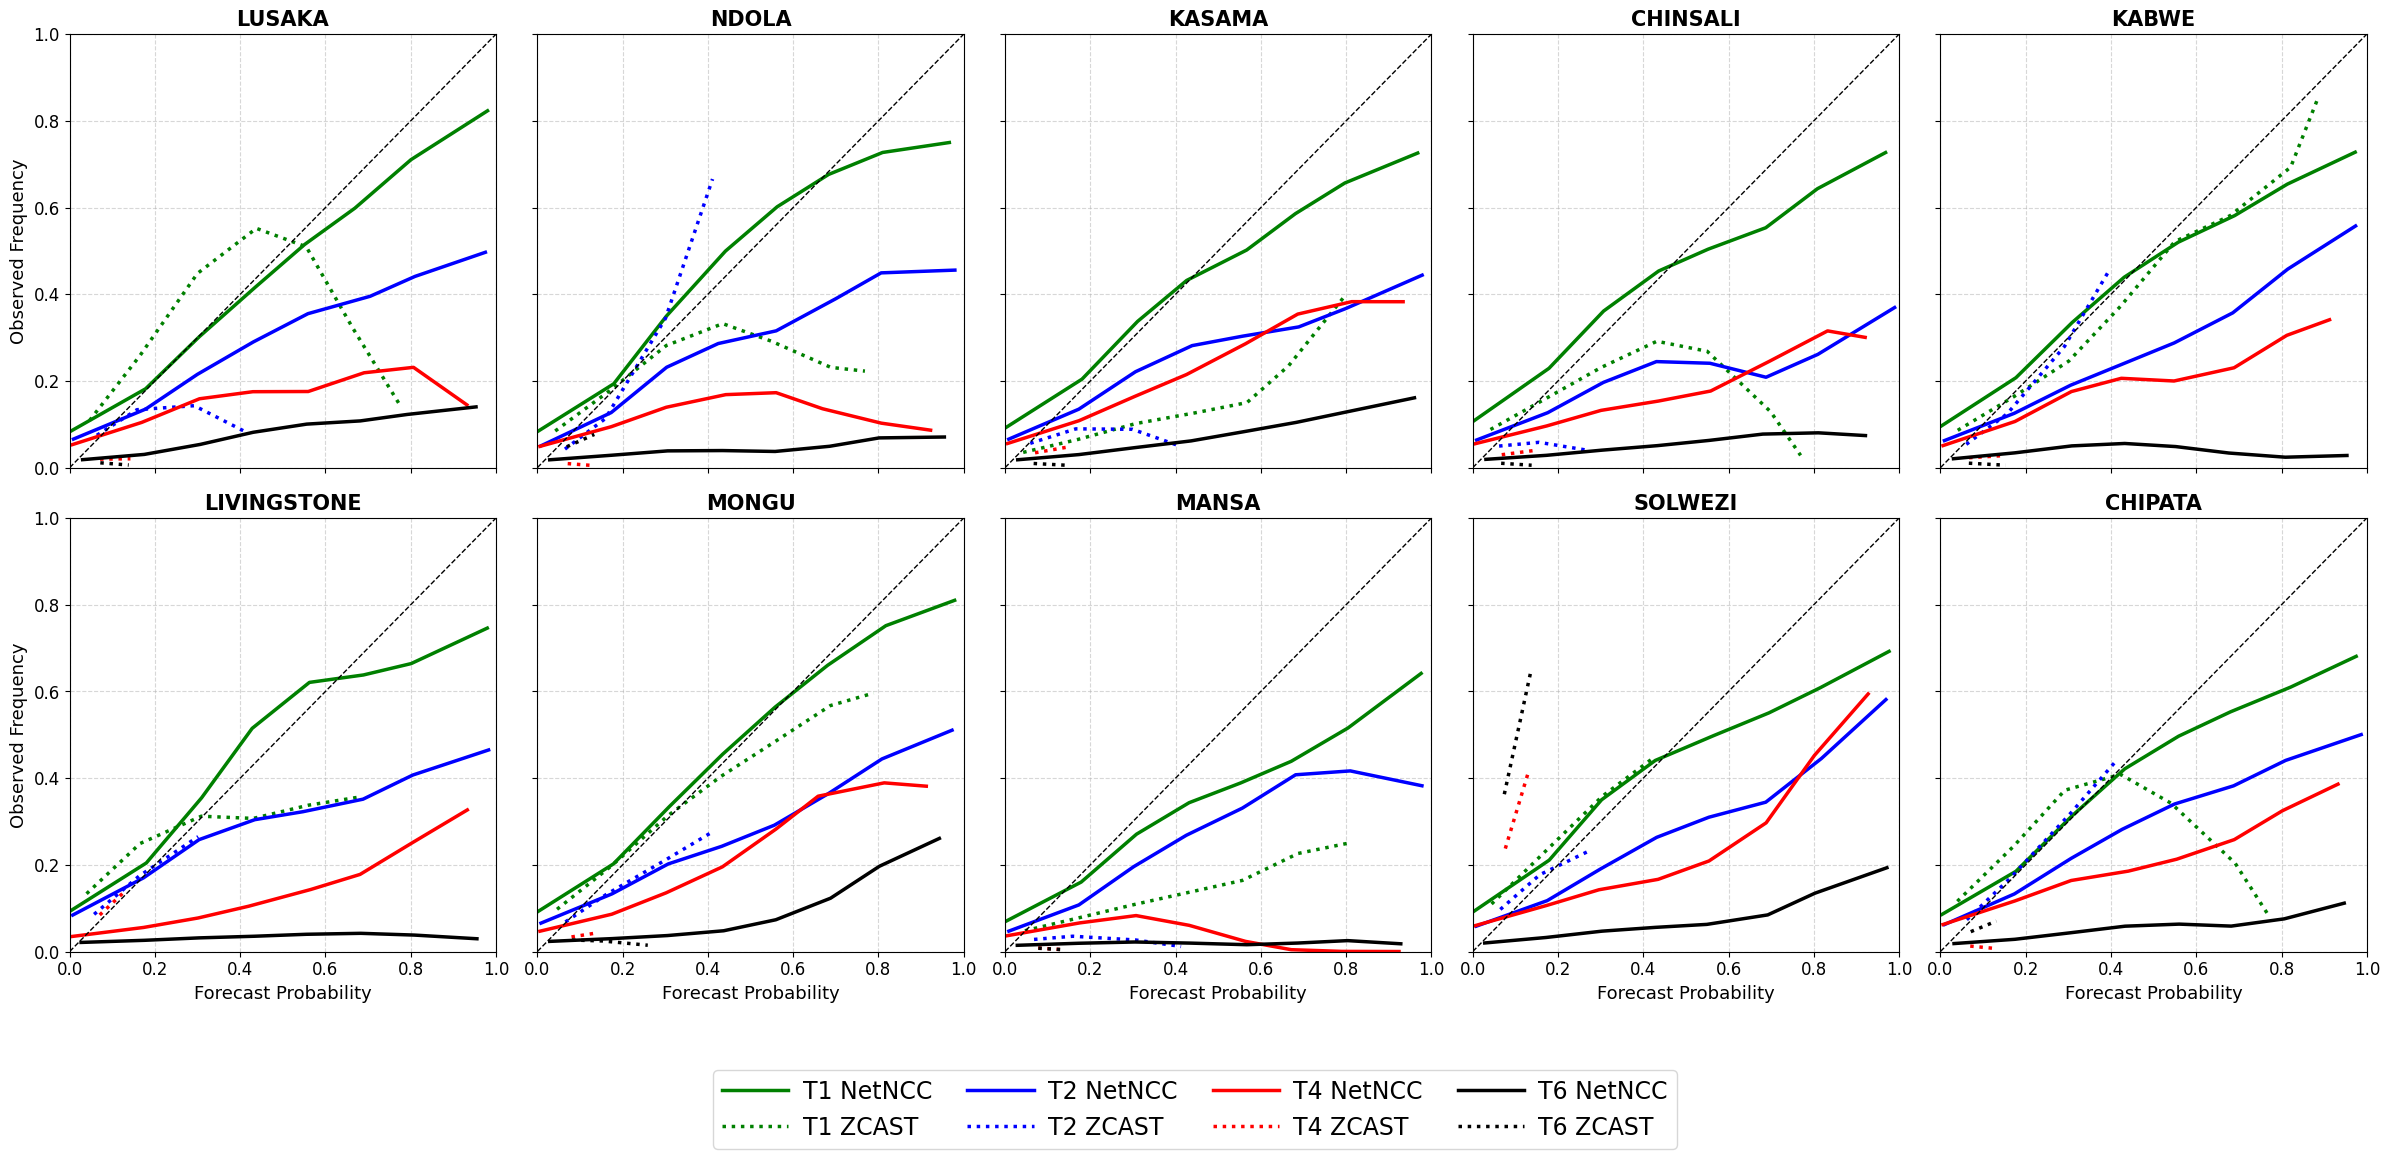

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(24, 11))
axes = axes.flatten()

colors = {"t1": "green", "t2": "blue", "t4": "red", "t6": "black"}
handles_all, labels_all = [], []

for i, city in enumerate(cities[:10]):
    ax = axes[i]
    drawn = False

    for lt in lead_times:
        df_nc = netncc[lt]
        df_zc = zcast[lt]
        gt_col = f"{city}_gt_lt{lt[-1]}"
        if gt_col not in df_nc.columns or f"{city}_{lt}" not in df_nc.columns or f"{city}_{lt}" not in df_zc.columns:
            continue

        merged = pd.merge(
            df_nc[["t0", gt_col, f"{city}_{lt}"]],
            df_zc[["t0", f"{city}_{lt}"]],
            on="t0",
            suffixes=("_ncc", "_zc")
        )

        y_true = merged[gt_col]
        y_pred_netncc = merged[f"{city}_{lt}_ncc"].replace(-998.0, np.nan)
        y_pred_zcast = merged[f"{city}_{lt}_zc"].replace(-998.0, np.nan)

        # Convert to probability if needed
        if y_pred_netncc.max() > 1:
            y_pred_netncc /= 100.0
        if y_pred_zcast.max() > 1:
            y_pred_zcast /= 100.0

        y_pred_netncc = y_pred_netncc.clip(0, 1)
        y_pred_zcast = y_pred_zcast.clip(0, 1)

        mask_nc = ~y_pred_netncc.isna()
        mask_zc = ~y_pred_zcast.isna()
        if mask_nc.sum() < 30 or mask_zc.sum() < 30:
            continue

        # Fixed uniform bins to avoid empty output
        n_bins = 8
        prob_true_ncc, prob_pred_ncc = calibration_curve(
            y_true[mask_nc], y_pred_netncc[mask_nc], n_bins=n_bins, strategy="uniform"
        )
        prob_true_zc, prob_pred_zc = calibration_curve(
            y_true[mask_zc], y_pred_zcast[mask_zc], n_bins=n_bins, strategy="uniform"
        )

        # Smooth slightly for clarity
        prob_true_ncc = gaussian_filter1d(prob_true_ncc, sigma=1)
        prob_true_zc = gaussian_filter1d(prob_true_zc, sigma=1)

        # Plot
        l1, = ax.plot(prob_pred_ncc, prob_true_ncc, color=colors[lt], lw=2.5, ls="-")
        l2, = ax.plot(prob_pred_zc, prob_true_zc, color=colors[lt], lw=2.5, ls=":")

        drawn = True

        if i == 0:
            handles_all.extend([l1, l2])
            labels_all.extend([f"{lt.upper()} NetNCC", f"{lt.upper()} ZCAST"])

    # Perfect calibration line
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(city.upper(), fontsize=15, weight="bold")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.tick_params(axis="both", labelsize=12)

    # Label placement
    if i >= 5:
        ax.set_xlabel("Forecast Probability", fontsize=13)
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])

    if i % 5 == 0:
        ax.set_ylabel("Observed Frequency", fontsize=13)
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])

    if not drawn:
        ax.text(0.5, 0.5, "No valid data", ha="center", va="center",
                fontsize=12, color="grey")

plt.subplots_adjust(hspace=0.45, wspace=0.25)

fig.legend(
    handles_all,
    labels_all,
    loc="lower center",
    fontsize=17,
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    edgecolor="lightgrey",
    ncol=4,
    handlelength=2.8,
    handletextpad=0.6,
    columnspacing=1.5,
    bbox_to_anchor=(0.5, -0.06)
)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

<Figure size 1000x1000 with 0 Axes>

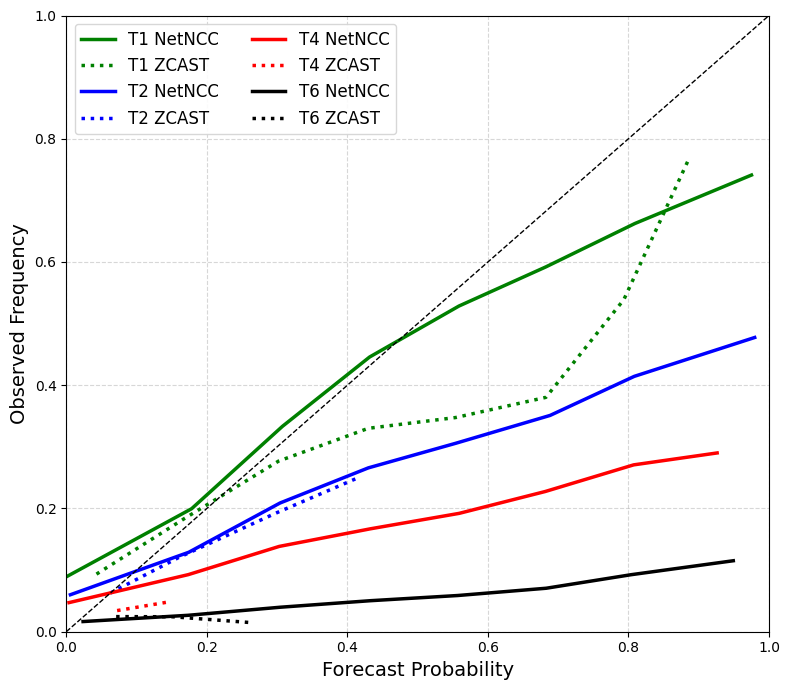

In [14]:
plt.figure(figsize=(10, 10))

lead_times = ["t1", "t2", "t4", "t6"]
base_dir = "/gws/nopw/j04/wiser_ewsa/mrakotomanga/Intercomparison/time_series"

# Load data
netncc = {lt: pd.read_csv(f"{base_dir}/netncc/{lt}/zambia_nowcasts_{lt}.csv") for lt in lead_times}
zcast  = {lt: pd.read_csv(f"{base_dir}/zcast/{lt}/zambia_nowcasts_{lt}.csv") for lt in lead_times}
cities = [col.replace("_t1", "") for col in netncc["t1"].columns if col.endswith("_t1")]

# ---------------------------------------------------------------------
# Aggregate per model directly
# ---------------------------------------------------------------------
def collect_all(model_dict):
    all_y_true, all_y_pred = {}, {}
    for lt in lead_times:
        y_true_all, y_pred_all = [], []
        df = model_dict[lt]
        for city in cities:
            gt_col = f"{city}_gt_lt{lt[-1]}"
            pred_col = f"{city}_{lt}"
            if gt_col not in df.columns or pred_col not in df.columns:
                continue
            y_true = df[gt_col]
            y_pred = df[pred_col].replace(-998.0, np.nan)
            if y_pred.max() > 1:
                y_pred /= 100.0
            y_pred = y_pred.clip(0, 1)
            mask = ~y_pred.isna()
            if mask.sum() < 30 or y_true[mask].nunique() < 2:
                continue
            y_true_all.append(y_true[mask])
            y_pred_all.append(y_pred[mask])
        if y_true_all:
            all_y_true[lt] = pd.concat(y_true_all, ignore_index=True)
            all_y_pred[lt] = pd.concat(y_pred_all, ignore_index=True)
    return all_y_true, all_y_pred

y_true_nc, y_pred_nc = collect_all(netncc)
y_true_zc, y_pred_zc = collect_all(zcast)

# ---------------------------------------------------------------------
# Compute calibration curves per lead time
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 7))
colors = {"t1": "green", "t2": "blue", "t4": "red", "t6": "black"}

for lt in lead_times:
    if lt not in y_true_nc or lt not in y_true_zc:
        continue

    n_bins = 8
    prob_true_nc, prob_pred_nc = calibration_curve(y_true_nc[lt], y_pred_nc[lt], n_bins=n_bins, strategy="uniform")
    prob_true_zc, prob_pred_zc = calibration_curve(y_true_zc[lt], y_pred_zc[lt], n_bins=n_bins, strategy="uniform")

    # Smooth for clarity
    prob_true_nc = gaussian_filter1d(prob_true_nc, sigma=1)
    prob_true_zc = gaussian_filter1d(prob_true_zc, sigma=1)

    plt.plot(prob_pred_nc, prob_true_nc, color=colors[lt], lw=2.5, ls="-", label=f"{lt.upper()} NetNCC")
    plt.plot(prob_pred_zc, prob_true_zc, color=colors[lt], lw=2.5, ls=":", label=f"{lt.upper()} ZCAST")

# ---------------------------------------------------------------------
# Plot formatting
# ---------------------------------------------------------------------
plt.plot([0, 1], [0, 1], "k--", lw=1.0)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel("Forecast Probability", fontsize=14)
plt.ylabel("Observed Frequency", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(
    fontsize=12,
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    edgecolor="lightgrey",
    ncol=2
)
plt.tight_layout()
plt.show()


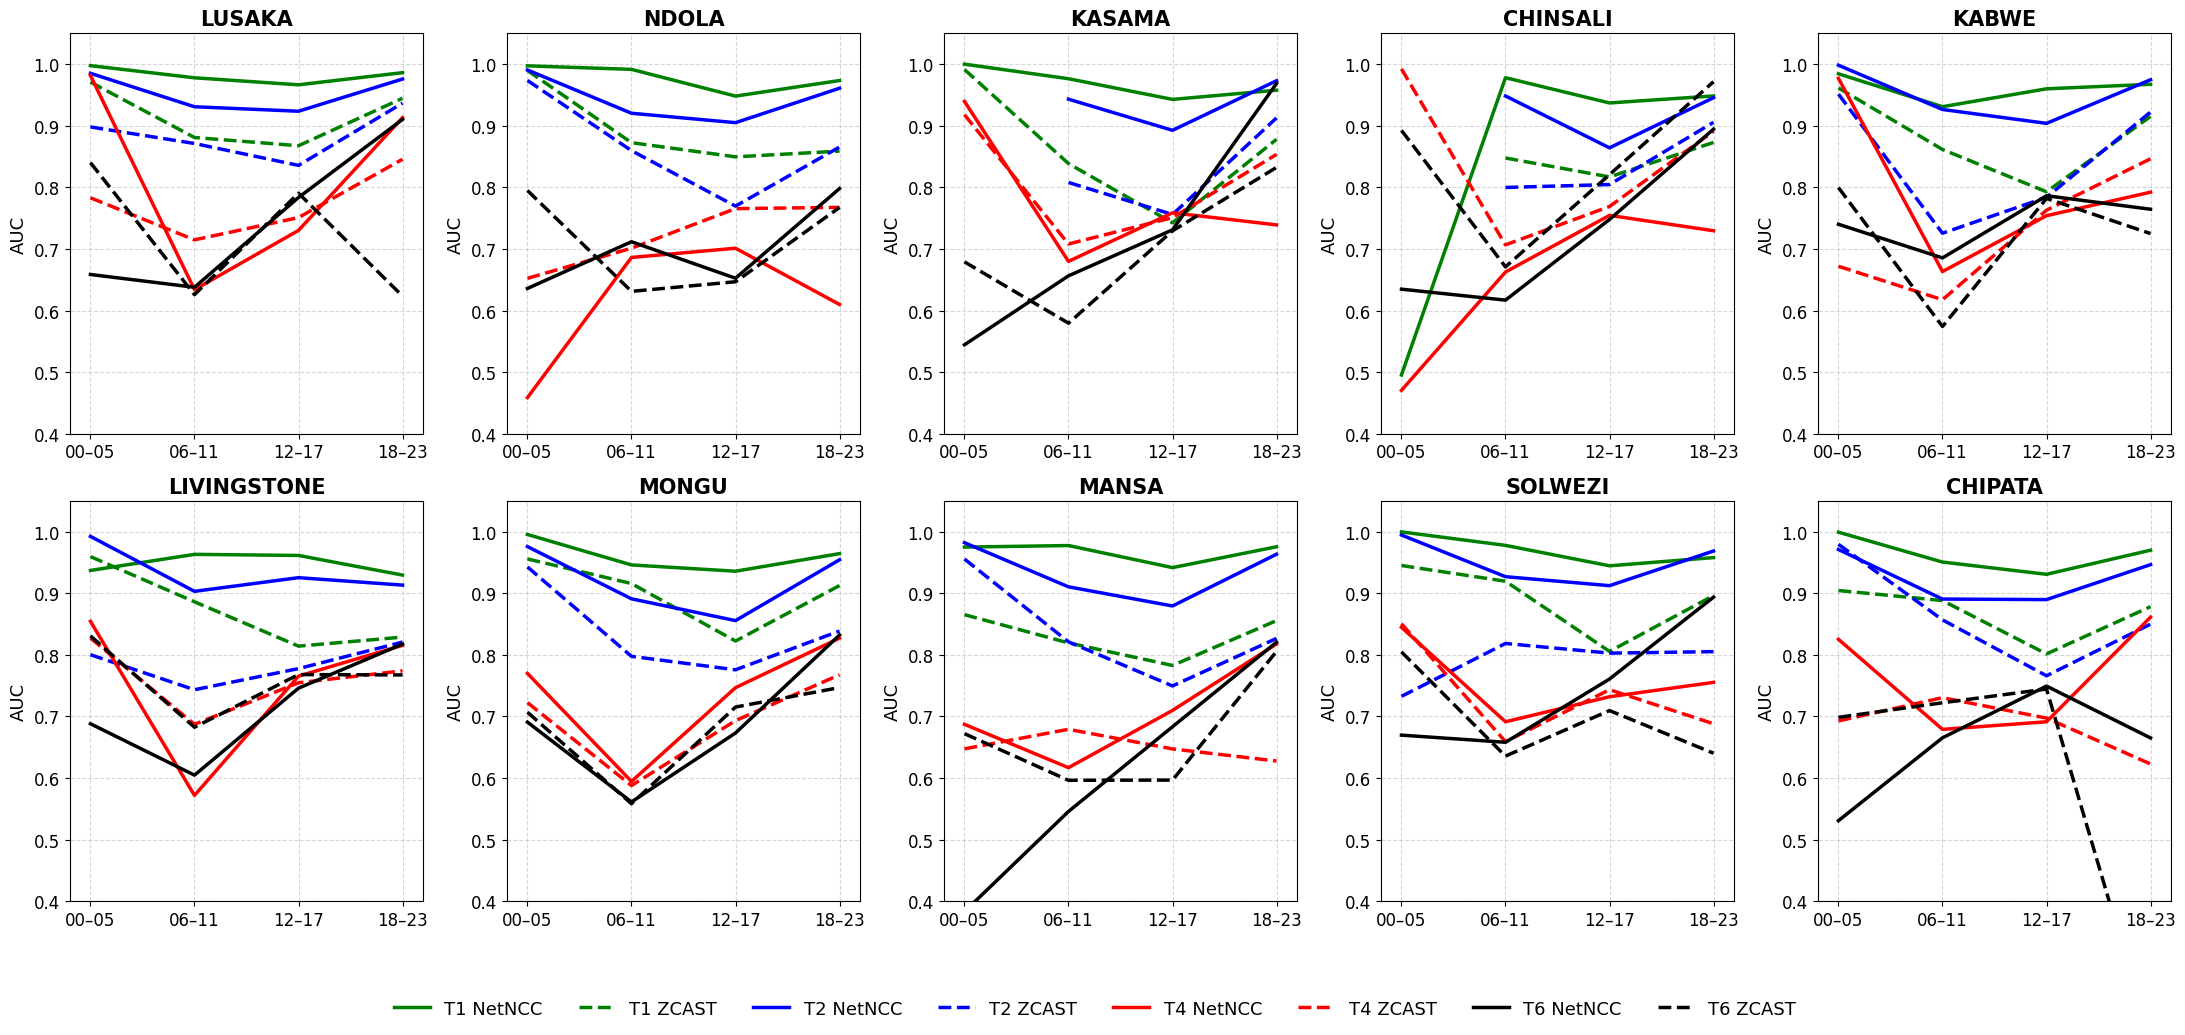

In [10]:
def merge_all_leads(model_data, model_name):
    df_list = []
    for lt, df in model_data.items():
        df = df.copy()
        df["lead_time"] = lt
        df["model"] = model_name
        df["t0"] = pd.to_datetime(df["t0"])
        df_list.append(df)
    return pd.concat(df_list, ignore_index=True)

df_zcast = merge_all_leads(zcast, "ZCAST")
df_netncc = merge_all_leads(netncc, "NetNCC")

# ---------------------------------------------------------------------
# Define 4 time windows
# ---------------------------------------------------------------------
def time_window(hour):
    if 0 <= hour < 6:
        return "00–05"
    elif 6 <= hour < 12:
        return "06–11"
    elif 12 <= hour < 18:
        return "12–17"
    else:
        return "18–23"

# ---------------------------------------------------------------------
# Compute mean AUC for each city / model / lead_time / window
# ---------------------------------------------------------------------
results = []
for city in cities:
    for model_name, df_model in [("ZCAST", df_zcast), ("NetNCC", df_netncc)]:
        for lt in lead_times:
            gt_col = f"{city}_gt_lt{lt[-1]}"
            pred_col = f"{city}_{lt}"
            if gt_col not in df_model.columns:
                continue

            df_sub = df_model[["t0", gt_col, pred_col]].copy()
            df_sub = df_sub.rename(columns={gt_col: "gt", pred_col: "pred"})
            df_sub["pred"] = df_sub["pred"].replace(-998.0, np.nan)
            df_sub = df_sub.dropna()
            df_sub["window"] = df_sub["t0"].dt.hour.apply(time_window)

            for w, group in df_sub.groupby("window"):
                if group["gt"].nunique() < 2:
                    continue
                auc_val = roc_auc_score(group["gt"], group["pred"])
                results.append({
                    "city": city,
                    "model": model_name,
                    "lead_time": lt,
                    "window": w,
                    "auc": auc_val
                })

auc_df = pd.DataFrame(results)
windows = ["00–05", "06–11", "12–17", "18–23"]

# ---------------------------------------------------------------------
# Plot AUC vs time window (ZCAST vs NetNCC)
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

colors = {"t1": "green", "t2": "blue", "t4": "red", "t6": "black"}

for i, city in enumerate(cities[:10]):
    ax = axes[i]
    sub = auc_df[auc_df["city"] == city]
    if sub.empty:
        continue

    for lt in lead_times:
        for model, linestyle in [("NetNCC", "-"), ("ZCAST", "--")]:
            df_f = sub[(sub["model"] == model) & (sub["lead_time"] == lt)]
            if df_f.empty:
                continue
            df_f = df_f.set_index("window").reindex(windows)
            label = f"{lt.upper()} {model}"
            ax.plot(np.arange(len(windows)), df_f["auc"], color=colors[lt], lw=2.5, ls=linestyle, label=label)

    ax.set_title(city.upper(), fontsize=15, weight="bold")
    ax.set_xticks(np.arange(len(windows)))
    ax.set_xticklabels(windows, fontsize=12)
    ax.set_xlim([-0.2, len(windows) - 0.8])
    ax.set_ylim([0.4, 1.05])
    ax.set_ylabel("AUC", fontsize=13)
    ax.tick_params(axis="y", labelsize=12)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.subplots_adjust(hspace=0.4, wspace=0.25)

# ---------------------------------------------------------------------
# Horizontal legend below all subplots
# ---------------------------------------------------------------------
handles = []
for lt in lead_times:
    for model, linestyle in [("NetNCC", "-"), ("ZCAST", "--")]:
        handles.append(
            plt.Line2D([0], [0], color=colors[lt], lw=2.5, ls=linestyle, label=f"{lt.upper()} {model}")
        )

fig.legend(
    handles=handles,
    loc="lower center",
    fontsize=13,
    frameon=False,
    ncol=8,
    bbox_to_anchor=(0.5, -0.04)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


In [11]:
# ---------------------------------------------------------------------
# Helper function to assign hour-based windows
# ---------------------------------------------------------------------
def time_window(hour):
    if 0 <= hour <= 5:
        return "00–05"
    elif 6 <= hour <= 11:
        return "06–11"
    elif 12 <= hour <= 17:
        return "12–17"
    else:
        return "18–23"


# ---------------------------------------------------------------------
# Compute Brier Skill Score (model vs NFLICS baseline)
# ---------------------------------------------------------------------
def compute_bss_vs_nflics(model_dict, model_name):
    results = []
    for city in cities:
        for lt in lead_times:
            gt_col = f"{city}_gt_lt{lt[-1]}"
            pred_col = f"{city}_{lt}"
            if gt_col not in nflics[lt].columns or gt_col not in model_dict[lt].columns:
                continue

            df_nf = nflics[lt][["t0", gt_col, pred_col]].copy()
            df_md = model_dict[lt][["t0", gt_col, pred_col]].copy()

            df_nf = df_nf.rename(columns={gt_col: "gt", pred_col: "pred_nf"})
            df_md = df_md.rename(columns={gt_col: "gt", pred_col: "pred_md"})

            # Merge and clean
            df_merge = pd.merge(df_nf, df_md, on=["t0", "gt"])
            df_merge["pred_nf"] = df_merge["pred_nf"].replace(-998.0, np.nan)
            df_merge["pred_md"] = df_merge["pred_md"].replace(-998.0, np.nan)
            df_merge = df_merge.dropna()

            if df_merge.empty:
                continue

            # Convert t0 to datetime
            if not np.issubdtype(df_merge["t0"].dtype, np.datetime64):
                df_merge["t0"] = pd.to_datetime(df_merge["t0"], errors="coerce")
            df_merge = df_merge.dropna(subset=["t0"])

            # Scale if needed
            for c in ["pred_nf", "pred_md"]:
                if df_merge[c].max() > 1:
                    df_merge[c] /= 100.0
                df_merge[c] = df_merge[c].clip(0, 1)

            # Assign window
            df_merge["window"] = df_merge["t0"].dt.hour.apply(time_window)

            for w, group in df_merge.groupby("window"):
                if group["gt"].nunique() < 2:
                    continue

                p_nf = group["pred_nf"]
                p_md = group["pred_md"]

                bs_ref = brier_score_loss(group["gt"], p_nf)
                bs_model = brier_score_loss(group["gt"], p_md)
                bss = 1 - bs_model / (bs_ref + 1e-12)

                results.append({
                    "city": city,
                    "lead_time": lt,
                    "window": w,
                    "bss": bss,
                    "model": model_name
                })
    return pd.DataFrame(results)


# ---------------------------------------------------------------------
# Compute both comparisons
# ---------------------------------------------------------------------
bss_netncc = compute_bss_vs_nflics(netncc, "NetNCC")
bss_zcast = compute_bss_vs_nflics(zcast, "ZCAST")

bss_df = pd.concat([bss_netncc, bss_zcast], ignore_index=True)
windows = ["00–05", "06–11", "12–17", "18–23"]


# ---------------------------------------------------------------------
# Plot: two rows — NetNCC vs NFLICS and ZCAST vs NFLICS
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(22, 12), dpi=600)
axes = axes.flatten()

colors = {"t1": "green", "t2": "blue", "t4": "red", "t6": "black"}

for i, city in enumerate(cities[:10]):
    ax = axes[i]
    sub = bss_df[bss_df["city"] == city]
    if sub.empty:
        continue

    for model_name, ls in zip(["NetNCC", "ZCAST"], ["-", ":"]):
        sub_m = sub[sub["model"] == model_name]
        for lt in lead_times:
            df_f = sub_m[sub_m["lead_time"] == lt]
            if df_f.empty:
                continue
            df_f = df_f.set_index("window").reindex(windows)
            ax.plot(
                np.arange(len(windows)),
                df_f["bss"],
                color=colors[lt],
                lw=2.5,
                marker="o",
                ls=ls,
                label=f"{lt.upper()} {model_name}"
            )

    ax.axhline(0, color="k", lw=1.0, linestyle="--")
    ax.set_title(city.upper(), fontsize=15, weight="bold")
    ax.set_xticks(np.arange(len(windows)))
    ax.set_xticklabels(windows, fontsize=12)
    ax.set_xlim([-0.2, len(windows) - 0.8])
    ax.set_ylim([-1.0, 1.0])
    ax.tick_params(axis="both", labelsize=11)
    ax.grid(True, linestyle="--", alpha=0.5)

    if i < 5:
        ax.set_xlabel("")
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Time Window", fontsize=13)

    if i % 5 == 0:
        ax.set_ylabel("Brier Skill Score (vs NFLICS)", fontsize=13)
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])

plt.subplots_adjust(hspace=0.35, wspace=0.25)

# ---------------------------------------------------------------------
# Legend below all panels
# ---------------------------------------------------------------------
handles = []
for model_name, ls in zip(["NetNCC", "ZCAST"], ["-", ":"]):
    for lt in lead_times:
        handles.append(
            plt.Line2D(
                [0], [0], color=colors[lt], lw=2.5, marker="o", ls=ls,
                label=f"{lt.upper()} {model_name}"
            )
        )

fig.legend(
    handles=handles,
    loc="lower center",
    fontsize=14,
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    edgecolor="lightgrey",
    ncol=4,
    handlelength=2.8,
    handletextpad=0.6,
    columnspacing=1.5,
    bbox_to_anchor=(0.5, -0.01)
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

In [12]:
# ---------------------------------------------------------------------
# Helper: assign hour-based time windows
# ---------------------------------------------------------------------
def time_window(hour):
    if 0 <= hour <= 5:
        return "00–05"
    elif 6 <= hour <= 11:
        return "06–11"
    elif 12 <= hour <= 17:
        return "12–17"
    else:
        return "18–23"


# ---------------------------------------------------------------------
# Function to compute BSS vs NFLICS for a given model
# ---------------------------------------------------------------------
def compute_bss_vs_nflics(model_dict, model_name):
    results = []
    for city in cities:
        for lt in lead_times:
            gt_col = f"{city}_gt_lt{lt[-1]}"
            pred_col = f"{city}_{lt}"
            if gt_col not in nflics[lt].columns or gt_col not in model_dict[lt].columns:
                continue

            df_nf = nflics[lt][["t0", gt_col, pred_col]].copy()
            df_md = model_dict[lt][["t0", gt_col, pred_col]].copy()

            df_nf = df_nf.rename(columns={gt_col: "gt", pred_col: "pred_nf"})
            df_md = df_md.rename(columns={gt_col: "gt", pred_col: "pred_md"})

            # Merge and clean
            df_merge = pd.merge(df_nf, df_md, on=["t0", "gt"])
            df_merge["pred_nf"] = df_merge["pred_nf"].replace(-998.0, np.nan)
            df_merge["pred_md"] = df_merge["pred_md"].replace(-998.0, np.nan)
            df_merge = df_merge.dropna()

            if df_merge.empty:
                continue

            # Ensure datetime
            df_merge["t0"] = pd.to_datetime(df_merge["t0"], errors="coerce")
            df_merge = df_merge.dropna(subset=["t0"])

            # Scale if needed
            for col in ["pred_nf", "pred_md"]:
                if df_merge[col].max() > 1:
                    df_merge[col] /= 100.0
                df_merge[col] = df_merge[col].clip(0, 1)

            df_merge["window"] = df_merge["t0"].dt.hour.apply(time_window)

            for w, group in df_merge.groupby("window"):
                if group["gt"].nunique() < 2:
                    continue

                p_nf = group["pred_nf"]
                p_md = group["pred_md"]

                bs_ref = brier_score_loss(group["gt"], p_nf)
                bs_model = brier_score_loss(group["gt"], p_md)
                bss = 1 - bs_model / (bs_ref + 1e-12)

                results.append({
                    "city": city,
                    "lead_time": lt,
                    "window": w,
                    "bss": bss,
                    "model": model_name
                })
    return pd.DataFrame(results)


# ---------------------------------------------------------------------
# Compute BSS(NetNCC vs NFLICS) and BSS(ZCAST vs NFLICS)
# ---------------------------------------------------------------------
bss_netncc = compute_bss_vs_nflics(netncc, "NetNCC")
bss_zcast = compute_bss_vs_nflics(zcast, "ZCAST")

# Merge on city / lead_time / window to compute ΔBSS = NetNCC - ZCAST
merged_bss = pd.merge(
    bss_netncc,
    bss_zcast,
    on=["city", "lead_time", "window"],
    suffixes=("_ncc", "_zc")
)
merged_bss["bss_diff"] = merged_bss["bss_ncc"] - merged_bss["bss_zc"]

windows = ["00–05", "06–11", "12–17", "18–23"]

# ---------------------------------------------------------------------
# Plot ΔBSS (NetNCC - ZCAST)
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(22, 10), dpi=600)
axes = axes.flatten()

colors = {"t1": "green", "t2": "blue", "t4": "red", "t6": "black"}

for i, city in enumerate(cities[:10]):
    ax = axes[i]
    sub = merged_bss[merged_bss["city"] == city]
    if sub.empty:
        continue

    for lt in lead_times:
        df_f = sub[sub["lead_time"] == lt]
        if df_f.empty:
            continue
        df_f = df_f.set_index("window").reindex(windows)
        ax.plot(
            np.arange(len(windows)),
            df_f["bss_diff"],
            color=colors[lt],
            lw=2.5,
            marker="o",
            label=f"{lt.upper()} ΔBSS"
        )

    ax.axhline(0, color="k", lw=1.0, linestyle="--")
    ax.set_title(city.upper(), fontsize=15, weight="bold")
    ax.set_xticks(np.arange(len(windows)))
    ax.set_xticklabels(windows, fontsize=12)
    ax.set_xlim([-0.2, len(windows) - 0.8])
    ax.set_ylim([-0.5, 0.5])
    ax.tick_params(axis="both", labelsize=11)
    ax.grid(True, linestyle="--", alpha=0.5)

    # Labels
    if i < 5:
        ax.set_xlabel("")
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Time Window", fontsize=13)

    if i % 5 == 0:
        ax.set_ylabel("ΔBSS (NetNCC − ZCAST)", fontsize=13)
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])

plt.subplots_adjust(hspace=0.35, wspace=0.25)

# ---------------------------------------------------------------------
# Legend below all panels
# ---------------------------------------------------------------------
handles = [
    plt.Line2D([0], [0], color=colors[lt], lw=2.5, marker="o", label=f"{lt.upper()} ΔBSS")
    for lt in lead_times
]

fig.legend(
    handles=handles,
    loc="lower center",
    fontsize=14,
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    edgecolor="lightgrey",
    ncol=4,
    handlelength=2.8,
    handletextpad=0.6,
    columnspacing=1.5,
    bbox_to_anchor=(0.5, -0.01)
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()
